In [1]:
import os
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rc("svg", fonttype="none")
sns.set(context="talk", style="ticks")
from scipy import stats

from lib.utils import constants

In [2]:
# Plot color
cols1 = sns.color_palette("Oranges", 2)
cols2 = sns.color_palette("Greens", 3)
cols3 = sns.color_palette("Purples", 3)
cols4 = sns.color_palette("Blues", 3)

In [3]:
# Load data
df = pd.read_csv("../data/cytotoxicity/dataset.csv")
df_mut = df[df.id != "wild-type"]

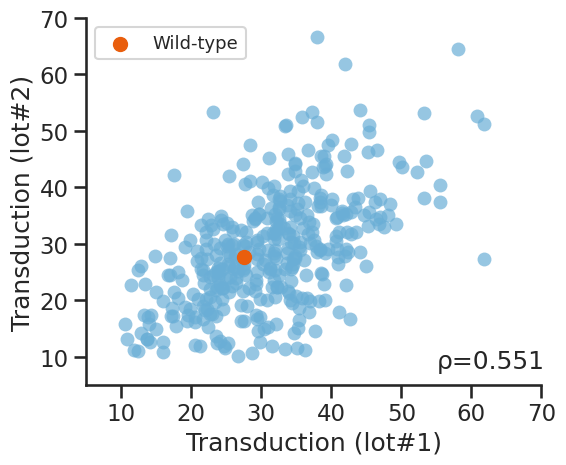

In [4]:
# Transduction
wt_val1 = df[df.id == "wild-type"]["transduction(lot#1)"].values.item()
wt_val2 = df[df.id == "wild-type"]["transduction(lot#2)"].values.item()
rho = stats.spearmanr(df_mut["transduction(lot#1)"], df_mut["transduction(lot#2)"]).statistic

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(df_mut["transduction(lot#1)"], df_mut["transduction(lot#2)"], s=100, alpha=0.7, linewidth=0, color=cols4[1])
ax.scatter([wt_val1], [wt_val2], color=cols1[1], alpha=1, s=100, linewidth=1.0, label="Wild-type")
ax.text(55, 8, f"ρ={rho:.3f}", fontsize=18)
ax.legend(loc="upper left", fontsize=13, frameon=True)
ax.set_xlim(5, 70)
ax.set_ylim(5, 70)
ax.set_xticks(np.arange(10, 80, 10))
ax.set_xlabel("Transduction (lot#1)")
ax.set_ylabel("Transduction (lot#2)")
sns.despine()
fig.tight_layout()
fig.savefig("./figures/transduction_donor-1_vs_donor-2.svg")

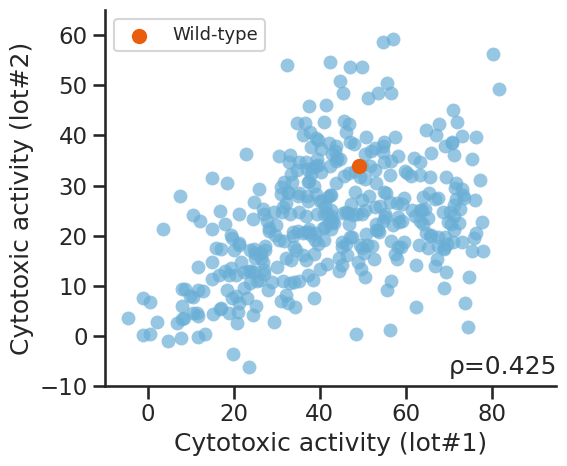

In [5]:
# Cytotoxicity
wt_val1 = df[df.id == "wild-type"]["cytotoxic_activity(lot#1)"].values.item()
wt_val2 = df[df.id == "wild-type"]["cytotoxic_activity(lot#2)"].values.item()
rho = stats.spearmanr(df_mut["cytotoxic_activity(lot#1)"], df_mut["cytotoxic_activity(lot#2)"]).statistic

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(df_mut["cytotoxic_activity(lot#1)"], df_mut["cytotoxic_activity(lot#2)"], s=100, alpha=0.7, linewidth=0, color=cols4[1])
ax.scatter([wt_val1], [wt_val2], color=cols1[1], alpha=1, s=100, linewidth=1.0, label="Wild-type")
ax.text(70, -7.5, f"ρ={rho:.3f}", fontsize=18)
ax.legend(loc="upper left", fontsize=13, frameon=True)
ax.set_xlim(-10, 95)
ax.set_ylim(-10, 65)
ax.set_xlabel("Cytotoxic activity (lot#1)")
ax.set_ylabel("Cytotoxic activity (lot#2)")
sns.despine()
fig.tight_layout()
fig.savefig("./figures/cytotoxicity_donor-1_vs_donor-2.svg")